In [63]:
filename = "Diabetes Classification.csv"
target_variable_name = "Diagnosis_index"

In [42]:
from pyspark.sql.functions import *

In [43]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()
data = spark.read.csv(filename, header=True, inferSchema=True, sep=',')
data.show()

+---+------+---+--------------+---+-----+--------------------------+-------+-------+--------+---------+
|Age|Gender|BMI|Blood Pressure|FBS|HbA1c|Family History of Diabetes|Smoking|   Diet|Exercise|Diagnosis|
+---+------+---+--------------+---+-----+--------------------------+-------+-------+--------+---------+
| 45|  Male| 25|        Normal|100|  5.7|                        No|     No|Healthy| Regular|       No|
| 55|Female| 30|          High|120|  6.4|                       Yes|    Yes|   Poor|      No|      Yes|
| 65|  Male| 35|          High|140|  7.1|                       Yes|    Yes|   Poor|      No|      Yes|
| 75|Female| 40|          High|160|  7.8|                       Yes|    Yes|   Poor|      No|      Yes|
| 40|  Male| 20|        Normal| 80|  5.0|                        No|     No|Healthy| Regular|       No|
| 50|Female| 25|        Normal|100|  5.7|                        No|     No|Healthy| Regular|       No|
| 60|  Male| 30|        Normal|120|  6.4|                       

# EDA

## Basic Statistics

In [44]:
data.count()

128

In [45]:
data.describe().toPandas()

,summary,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,count,128,128,128,128,128,128,128,128,128,128,128
1,mean,42.03125,None,35.359375,None,162.5,7.8875,None,None,None,None,None
2,stddev,16.783915012582924,None,14.981739212872439,None,61.32397509343179,2.146339128270113,None,None,None,None,None
3,min,12,Female,10,High,80,5.0,No,No,Healthy,No,No
4,max,75,Male,67,Normal,280,12.0,Yes,Yes,Poor,Regular,Yes


In [46]:
data.dtypes

[('Age', 'int'),
 ('Gender', 'string'),
 ('BMI', 'int'),
 ('Blood Pressure', 'string'),
 ('FBS', 'int'),
 ('HbA1c', 'double'),
 ('Family History of Diabetes', 'string'),
 ('Smoking', 'string'),
 ('Diet', 'string'),
 ('Exercise', 'string'),
 ('Diagnosis', 'string')]

In [47]:
data.printSchema()

root
 |-- Age: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- BMI: integer (nullable = true)
 |-- Blood Pressure: string (nullable = true)
 |-- FBS: integer (nullable = true)
 |-- HbA1c: double (nullable = true)
 |-- Family History of Diabetes: string (nullable = true)
 |-- Smoking: string (nullable = true)
 |-- Diet: string (nullable = true)
 |-- Exercise: string (nullable = true)
 |-- Diagnosis: string (nullable = true)



## Check for Missing Value

In [48]:
data.toPandas().isnull().sum()

Age                           0
Gender                        0
BMI                           0
Blood Pressure                0
FBS                           0
HbA1c                         0
Family History of Diabetes    0
Smoking                       0
Diet                          0
Exercise                      0
Diagnosis                     0
dtype: int64

## Check for Cardinality

In [49]:
data.toPandas().nunique()

Age                           35
Gender                         2
BMI                           34
Blood Pressure                 3
FBS                           11
HbA1c                         11
Family History of Diabetes     2
Smoking                        2
Diet                           2
Exercise                       2
Diagnosis                      2
dtype: int64

## Data Cleaning and Preparation

### Change Missing Value to Mean

In [50]:
for column in data.columns:
    mean_value = data.select(mean(col(column)).alias('mean')).collect()[0]["mean"]
    mode_value = data.select(mode(col(column)).alias('mode')).collect()[0]['mode']
    if mean_value is not None:
        data = data.na.fill(mean_value, [column])
    else :
        data = data.na.fill(mode_value, [column])

In [51]:
data.toPandas().isnull().sum()

Age                           0
Gender                        0
BMI                           0
Blood Pressure                0
FBS                           0
HbA1c                         0
Family History of Diabetes    0
Smoking                       0
Diet                          0
Exercise                      0
Diagnosis                     0
dtype: int64

## Label Encoding

In [52]:
from pyspark.ml.feature import StringIndexer
from pyspark.sql.types import StringType

def index_string_columns(df):
    string_columns = [t[0] for t in df.dtypes if t[1] == 'string']
    for column in string_columns:
        indexer = StringIndexer(inputCol=column, outputCol=column+"_index")
        df = indexer.fit(df).transform(df)
    return df

In [53]:
data = index_string_columns(data)

In [54]:
data.dtypes

[('Age', 'int'),
 ('Gender', 'string'),
 ('BMI', 'int'),
 ('Blood Pressure', 'string'),
 ('FBS', 'int'),
 ('HbA1c', 'double'),
 ('Family History of Diabetes', 'string'),
 ('Smoking', 'string'),
 ('Diet', 'string'),
 ('Exercise', 'string'),
 ('Diagnosis', 'string'),
 ('Gender_index', 'double'),
 ('Blood Pressure_index', 'double'),
 ('Family History of Diabetes_index', 'double'),
 ('Smoking_index', 'double'),
 ('Diet_index', 'double'),
 ('Exercise_index', 'double'),
 ('Diagnosis_index', 'double')]

### Drop all String/Object Variables

In [55]:
def variable_type(df):
    
    vars_list = df.dtypes
    char_vars = []
    num_vars = []
    for i in vars_list:
        if i[1] in ('string'):
            char_vars.append(i[0])
        else:
            num_vars.append(i[0])
    
    return char_vars, num_vars

In [56]:
char_vars, num_vars = variable_type(data)

data = data.select([c for c in data.columns if c not in char_vars])

In [57]:
data.printSchema()

root
 |-- Age: integer (nullable = true)
 |-- BMI: integer (nullable = true)
 |-- FBS: integer (nullable = true)
 |-- HbA1c: double (nullable = false)
 |-- Gender_index: double (nullable = false)
 |-- Blood Pressure_index: double (nullable = false)
 |-- Family History of Diabetes_index: double (nullable = false)
 |-- Smoking_index: double (nullable = false)
 |-- Diet_index: double (nullable = false)
 |-- Exercise_index: double (nullable = false)
 |-- Diagnosis_index: double (nullable = false)



## Visualization

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### Check for Normality

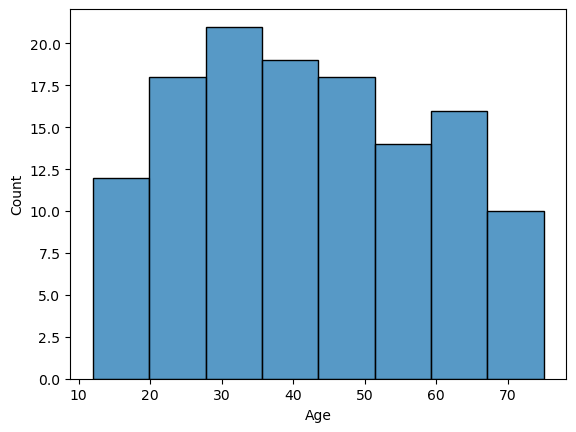

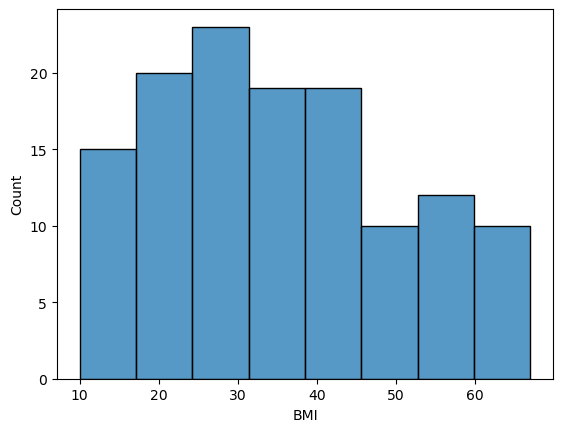

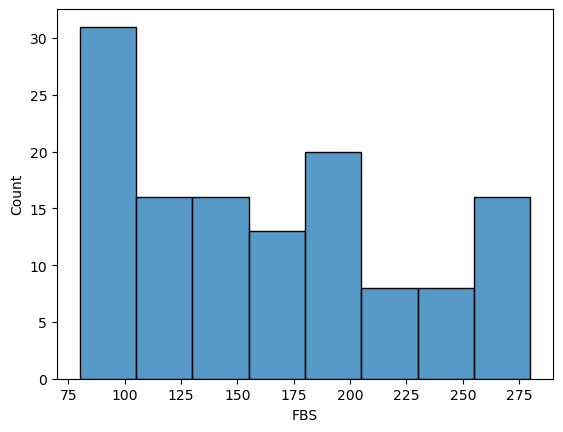

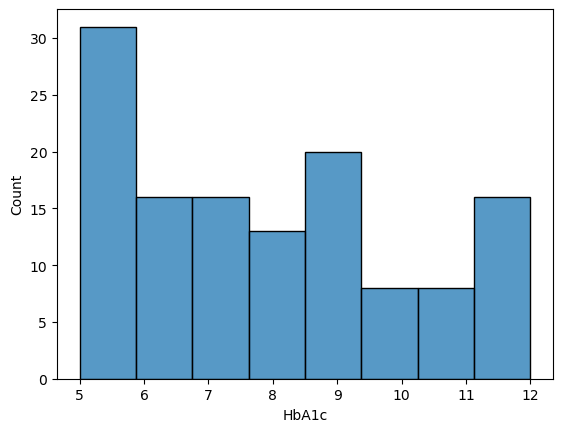

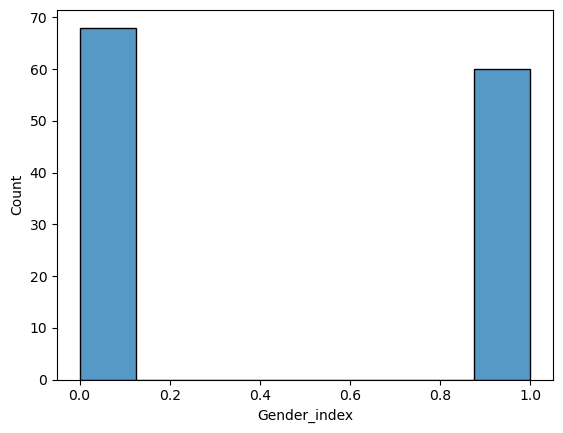

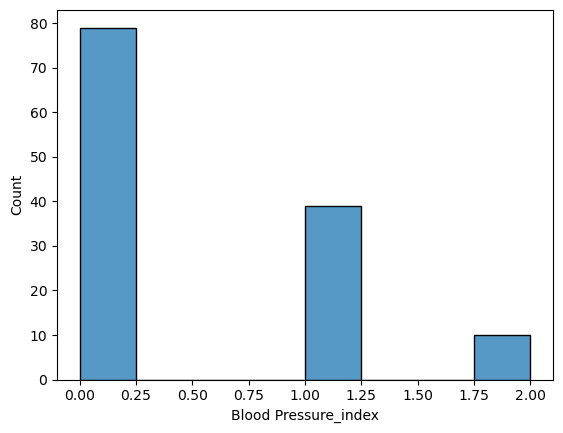

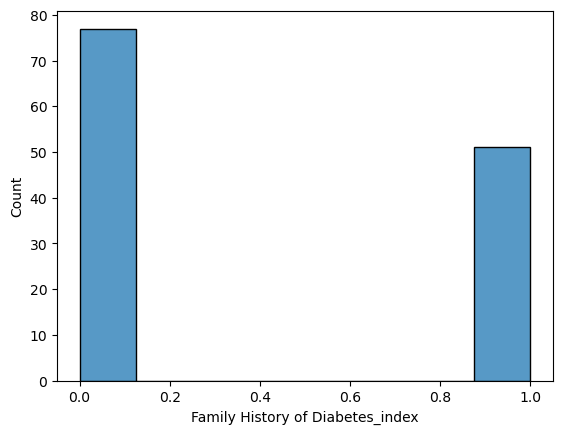

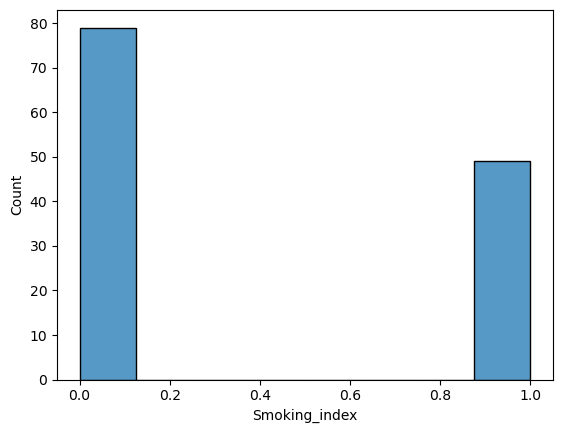

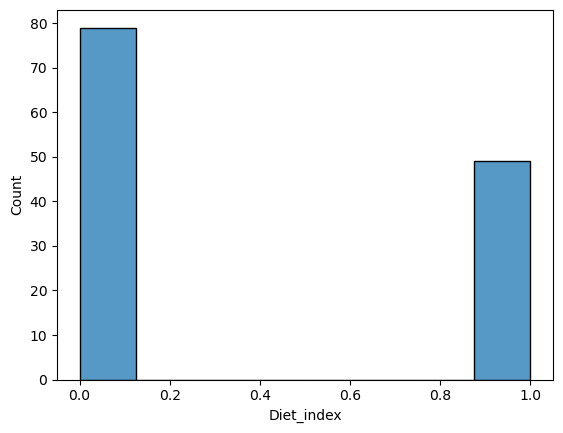

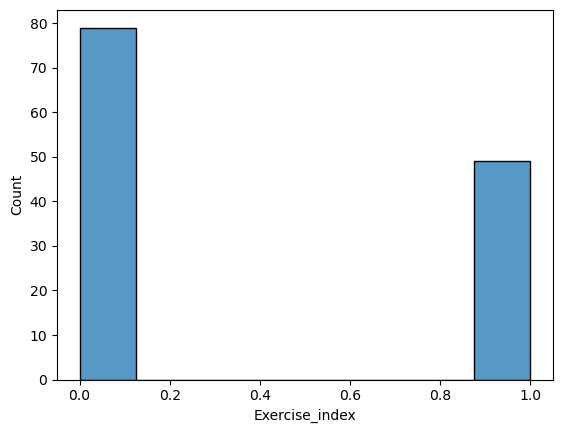

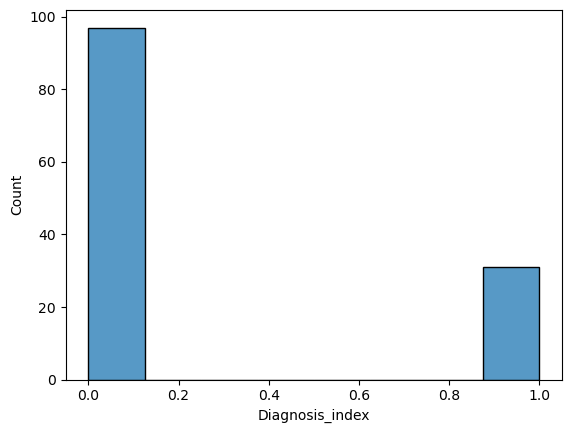

In [59]:
vis_df = data.toPandas()
for i, col in enumerate(vis_df.columns):
    plt.figure(i)
    sns.histplot(vis_df[col])

### Check for Correlation

<Axes: >

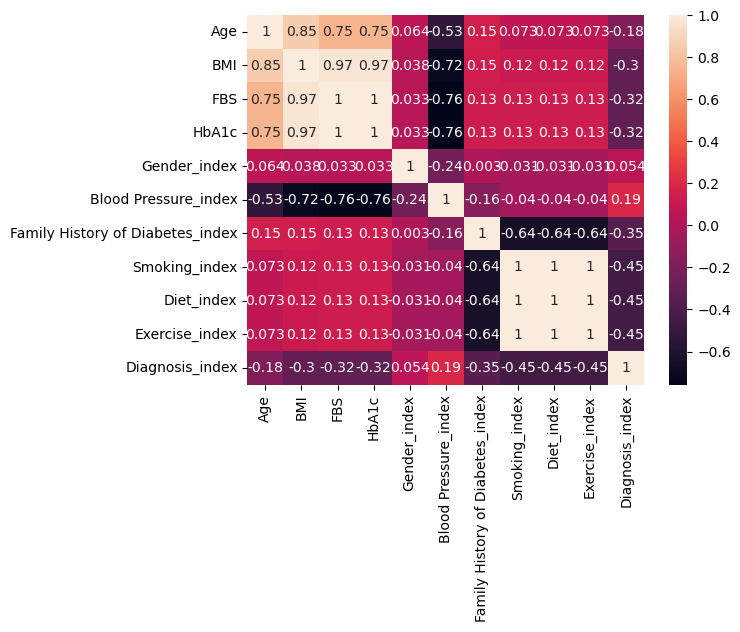

In [60]:
sns.heatmap(data.toPandas().corr(), annot=True)

From the Heatmap Above we can see that price is only correlated to squareMeters

# Model Data Preparation

### Split Data

In [61]:
train, test = data.randomSplit([0.7, 0.3], seed=12345)

In [64]:
#exclude target variable and select all other feature vectors
features_list = data.columns
#features_list = char_vars #this option is used only for ChiSqselector
features_list.remove(target_variable_name)

In [65]:
features_list

['Age',
 'BMI',
 'FBS',
 'HbA1c',
 'Gender_index',
 'Blood Pressure_index',
 'Family History of Diabetes_index',
 'Smoking_index',
 'Diet_index',
 'Exercise_index']

### Vector Assembling

In [66]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline

#assemble individual columns to one column - 'features'
def assemble_vectors(df, features_list, target_variable_name):
    stages = []
    #assemble vectors
    assembler = VectorAssembler(inputCols=features_list, outputCol='features')
    stages = [assembler]
    #select all the columns + target + newly created 'features' column
    selectedCols = [target_variable_name, 'features'] + features_list
    #use pipeline to process sequentially
    pipeline = Pipeline(stages=stages)
    #assembler model
    assembleModel = pipeline.fit(df)
    #apply assembler model on data
    df = assembleModel.transform(df).select(selectedCols)

    return df

In [67]:
df_assemble = assemble_vectors(train, features_list, target_variable_name)
df_test_assemble = assemble_vectors(test, features_list, target_variable_name)

In [68]:
df_assemble.show(5)

+---------------+--------------------+---+---+---+-----+------------+--------------------+--------------------------------+-------------+----------+--------------+
|Diagnosis_index|            features|Age|BMI|FBS|HbA1c|Gender_index|Blood Pressure_index|Family History of Diabetes_index|Smoking_index|Diet_index|Exercise_index|
+---------------+--------------------+---+---+---+-----+------------+--------------------+--------------------------------+-------------+----------+--------------+
|            0.0|[12.0,10.0,80.0,5...| 12| 10| 80|  5.0|         0.0|                 1.0|                             1.0|          0.0|       0.0|           0.0|
|            1.0|(10,[0,1,2,3,5],[...| 12| 10| 80|  5.0|         0.0|                 2.0|                             0.0|          0.0|       0.0|           0.0|
|            0.0|[12.0,10.0,80.0,5...| 12| 10| 80|  5.0|         0.0|                 2.0|                             0.0|          1.0|       1.0|           1.0|
|            0.0

# Modelling

## Linear Regression

In [71]:
from pyspark.ml.classification import LogisticRegression
LR_Class = LogisticRegression(featuresCol='features', labelCol=target_variable_name)
LR_Model = LR_Class.fit(df_assemble) # fit model

In [73]:
# Initialize a list to hold DataFrames
dfs = []

for k, v in df_assemble.schema["features"].metadata["ml_attr"]["attrs"].items():
    # Convert each dictionary in v to a DataFrame and add it to the list
    dfs.append(pd.DataFrame(v))

# Concatenate all the DataFrames in the list
features_df = pd.concat(dfs, ignore_index=True)

# print coefficient and intercept
print(LR_Model.coefficients, LR_Model.intercept)

features_df['coefficients'] = LR_Model.coefficients

[1.4712139608796995,-0.4851018648102105,-0.19224453575629438,-5.492701021608444,-1.6755835020329928,-19.4327763133201,-78.70135972248994,-34.01550097003163,-34.01550097003163,-34.01550097003163] 86.78533910104716


In [74]:
features_df

,idx,name,vals,coefficients
0,0,Age,NaN,1.471214
1,1,BMI,NaN,-0.485102
2,2,FBS,NaN,-0.192245
3,3,HbA1c,NaN,-5.492701
4,4,Gender_index,"[Male, Female]",-1.675584
5,5,Blood Pressure_index,"[High, Normal, Low]",-19.432776
6,6,Family History of Diabetes_index,"[No, Yes]",-78.701360
7,7,Smoking_index,"[Yes, No]",-34.015501
8,8,Diet_index,"[Poor, Healthy]",-34.015501
9,9,Exercise_index,"[No, Regular]",-34.015501


In [75]:
#prediction result
pred_result = LR_Model.transform(df_test_assemble)

### Logistic Regression Model Evaluation

In [88]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Initialize evaluator
evaluator = MulticlassClassificationEvaluator(labelCol=target_variable_name, predictionCol="prediction")

# Compute Evaluator on test data
accuracy = evaluator.evaluate(pred_result, {evaluator.metricName:'accuracy'})
recall = evaluator.evaluate(pred_result, {evaluator.metricName:'weightedRecall'})
precision = evaluator.evaluate(pred_result, {evaluator.metricName:'weightedPrecision'})
f1 = evaluator.evaluate(pred_result, {evaluator.metricName:'f1'})
print("Accuracy on test data = %g" % accuracy)
print("Recall on test data = %g" % recall)
print("Precision on test data = %g" % precision)
print("F1 on test data = %g" % f1)

Accuracy on test data = 0.892857
Recall on test data = 0.892857
Precision on test data = 0.928571
F1 on test data = 0.899652


## Decission Tree Classification

In [90]:
from pyspark.ml.classification import DecisionTreeClassifier
DT_Class = DecisionTreeClassifier(featuresCol='features', labelCol=target_variable_name)
DT_Model = DT_Class.fit(df_assemble) # fit model

In [91]:
#prediction result
dt_pred_result = DT_Model.transform(df_test_assemble)

### Decission Tree Model Evaluation

In [93]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Initialize evaluator
evaluator = MulticlassClassificationEvaluator(labelCol=target_variable_name, predictionCol="prediction")

# Compute Evaluator on test data
accuracy = evaluator.evaluate(dt_pred_result, {evaluator.metricName:'accuracy'})
recall = evaluator.evaluate(dt_pred_result, {evaluator.metricName:'weightedRecall'})
precision = evaluator.evaluate(dt_pred_result, {evaluator.metricName:'weightedPrecision'})
f1 = evaluator.evaluate(dt_pred_result, {evaluator.metricName:'f1'})
print("Accuracy on test data = %g" % accuracy)
print("Recall on test data = %g" % recall)
print("Precision on test data = %g" % precision)
print("F1 on test data = %g" % f1)

Accuracy on test data = 0.821429
Recall on test data = 0.821429
Precision on test data = 0.863409
F1 on test data = 0.832753
